# Exploratory Data Analysis

This notebook examines the dataset from https://www.kaggle.com/datasets/ronakbadhe/chess-evaluations. The goals of this notebook are:
1. Understand the structure and content of the dataset.
2. Identify any missing or inconsistent data.
3. Generate summary statistics and visualizations to uncover patterns and insights.

## Getting started

Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import sys
import chess
if ".." not in sys.path:
    sys.path.insert(0, '..')

from src.utils import batch_fen_to_tensor

Loading the dataset

In [ ]:
df = pd.read_csv("../dataset/raw/chess_data.csv", nrows=100000) # not reading full 12M+ dataset
# df_random = pd.read_csv("../dataset/raw/random_evals.csv")
# df_tactics = pd.read_csv("../dataset/raw/tactic_evals.csv")

Basic info

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   FEN         100000 non-null  object
 1   Evaluation  100000 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB


In [4]:
df.sample(5)

,FEN,Evaluation
61047,r1b2rk1/pp1n1ppp/4pn2/q1p3B1/1b1PP3/P1NB1N2/1P...,+96
5723,r1bq1rk1/pp2nppp/2nb4/1B1p4/3N4/1NP5/PP3PPP/R1...,-13
22761,3r2k1/4R1pp/p1q2pb1/2p5/PpN5/1P4QP/1P4P1/7K w ...,0
46884,r3k2r/pp2bppp/2n1p3/8/q7/2B1N3/PPP1QPPP/1K1R3R...,+51
9370,r1bqk2r/1p1nbp2/p3p3/2p3pn/4P3/2N1B3/PPPQN1PP/...,+46


Turning `Evaluation` column to `int`

In [5]:
df = df[~df["Evaluation"].str.contains("#")]

In [6]:
df["Evaluation"] = df["Evaluation"].astype(int)
df.sample(5)

,FEN,Evaluation
26073,6k1/p2n2pp/8/p2qB3/2pPr3/2P2Q1P/1R4K1/8 w - - ...,0
24105,r1bq1rk1/3nbppp/p1pp4/4p3/2P1PP2/2NB4/PP2Q1PP/...,113
21637,3r4/5k2/p6p/1p4p1/1P1B1pP1/5PnP/PP3K2/4R3 w - ...,126
45763,r2r1bk1/5p1p/8/pQqp4/3Rp3/2P3P1/1P2BP1P/3R2K1 ...,29
82407,8/p6r/2N2p2/3p4/3P2b1/4k1P1/PP5R/6K1 b - - 4 41,-95


In [7]:
df.describe()

,Evaluation
count,99446.000000
mean,37.356958
std,619.970342
min,-9024.000000
25%,-36.000000
50%,23.000000
75%,107.000000
max,7685.000000


Plotting the distribution of `Evaluation`

<Axes: ylabel='Frequency'>

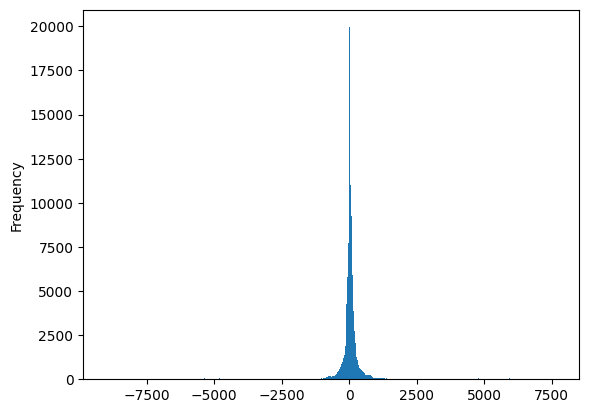

In [8]:
df['Evaluation'].plot.hist(bins=500)

Examining `FEN` column

In [9]:
df.sample(5)["FEN"].values

array(['2r3k1/1p1q1pp1/pR1prn1p/P3p3/4P3/2N4P/1PPRQPP1/6K1 w - - 1 25',
       'r2q1rk1/3nbpp1/pp1p3p/3Rp3/2P1P3/4BP2/PP2Q1PP/1K3B1R b - - 0 17',
       'rn1qkb1r/3ppp1p/5np1/2pP4/4P3/2N5/PP3PPP/R1BQKbNR w KQkq - 0 8',
       'q4rk1/5ppp/4pn2/1Q6/1P2bP2/P7/4B1PP/2BR3K w - - 1 27',
       '8/6R1/3K4/8/1pP1p3/1P3kp1/8/8 b - - 0 50'], dtype=object)

Converting `FEN` notation to suitable **tensor**

We’ll use this fixed order:

|Board #|Description|
|:-:|:-:|
|0|white pawn|
|1|white knight|
|2|white bishop|
|3|white rook|
|4|white queen|
|5|white king|
|6|black pawn|
|7|black knight|
|8|black bishop|
|9|black rook|
|10|black queen|
|11|black king|
|12|side to move (white=1, black=0)|
|13|white king-side castling|
|14|white queen-side castling|
|15|black king-side castling|
|16|black queen-side castling|
|17|en passant square|

In [21]:
samplee = df.sample().values[0]
samplee

array(['5rk1/p1n1b1pp/4qr2/3p4/NppP4/5R2/PPQ2BPP/3RN1K1 b - - 1 23', 273],
      dtype=object)

In [22]:
planes = batch_fen_to_tensor([samplee[0]])[0]
planes

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [1., 1., 0.,  ..., 0., 1., 1.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 1., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0., 

In [23]:
def plot_planes(planes: torch.Tensor = planes) -> None:
    plane_names = [
        "white pawn",
        "white knight",
        "white bishop",
        "white rook",
        "white queen",
        "white king",
        "black pawn",
        "black knight",
        "black bishop",
        "black rook",
        "black queen",
        "black king",
        "side to move (white=1, black=0)",
        "white king-side castling",
        "white queen-side castling",
        "black king-side castling",
        "black queen-side castling",
        "en passant square"
    ]
    planes = planes.cpu().numpy()

    fig, axes = plt.subplots(3, 6, figsize=(12, 6))
    axes = axes.flatten()

    for i in range(18):
        ax = axes[i]
        ax.imshow(planes[i], cmap="gray", vmin=0, vmax=1)
        ax.set_title(plane_names[i])
        ax.axis("off")

    plt.tight_layout()
    plt.show()

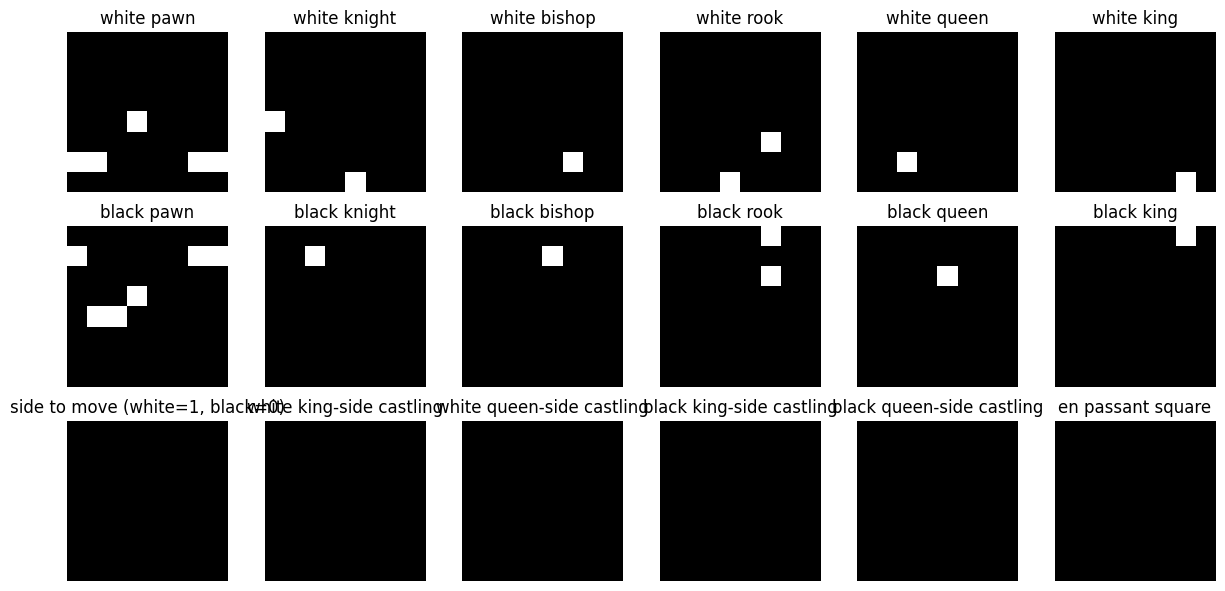

In [24]:
plot_planes(planes=planes)

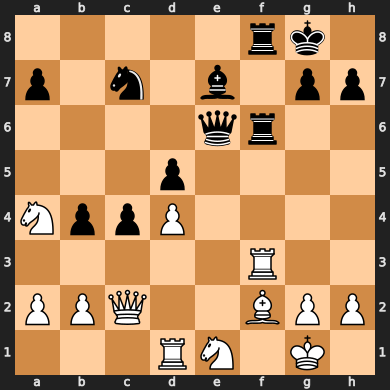

In [25]:
chess.Board(samplee[0])

In [26]:
print("Evaluation:", samplee[1])

Evaluation: 273


Examining outliers

In [38]:
position = df.sort_values(by="Evaluation").iloc[1]
position

FEN           2Q5/4b3/3p1k2/p5p1/5q2/5r1p/KPP5/8 w - - 5 50
Evaluation                                            -8308
Name: 88136, dtype: object

In [39]:
planes = batch_fen_to_tensor([position.iloc[0]])[0]
planes

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 1., 1.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0., 

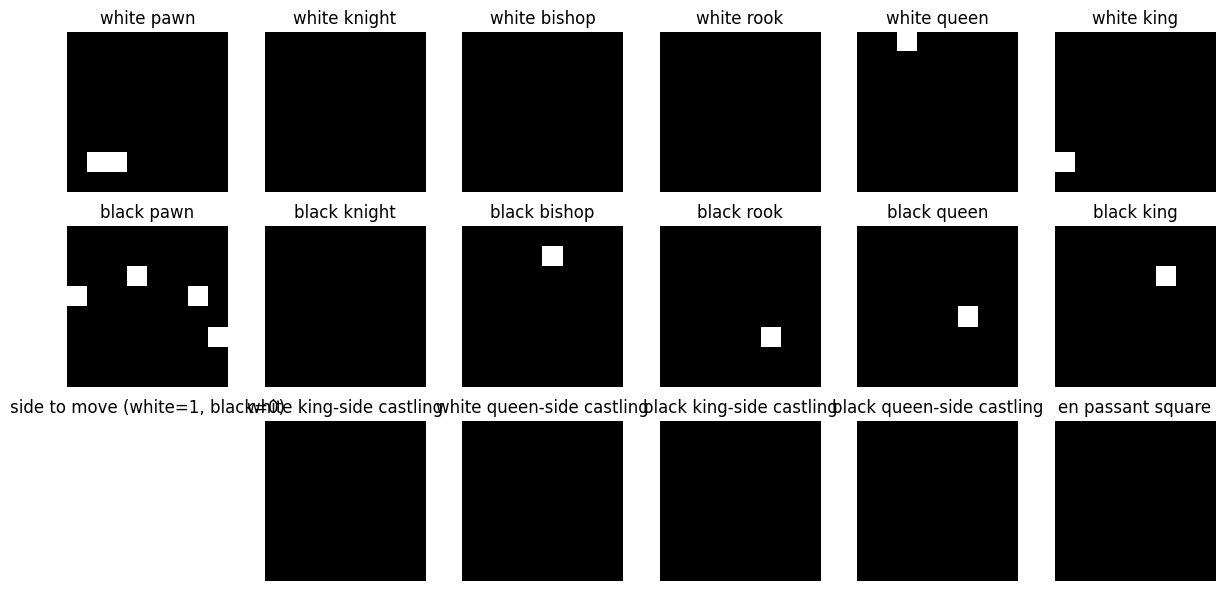

In [40]:
plot_planes(planes=planes)

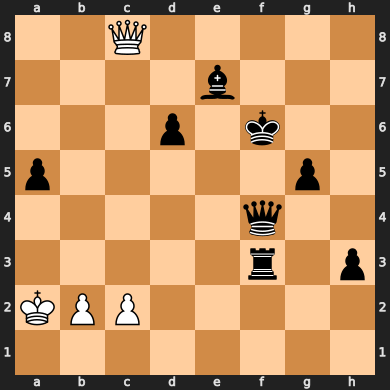

In [41]:
chess.Board(position.iloc[0])

In [42]:
print("Evaluation:", position.iloc[1])

Evaluation: -8308


In [47]:
df.FEN.to_list()

['rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1',
 'rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBNR w KQkq - 0 2',
 'rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBNR b KQkq - 0 2',
 'rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPP2PPP/RNBQKBNR w KQkq - 0 3',
 'rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPPN1PPP/R1BQKBNR b KQkq - 1 3',
 'rnbqkb1r/ppp2ppp/4pn2/3p4/3PP3/8/PPPN1PPP/R1BQKBNR w KQkq - 2 4',
 'rnbqkb1r/ppp2ppp/4pn2/3pP3/3P4/8/PPPN1PPP/R1BQKBNR b KQkq - 0 4',
 'rnbqkb1r/pppn1ppp/4p3/3pP3/3P4/8/PPPN1PPP/R1BQKBNR w KQkq - 1 5',
 'rnbqkb1r/pppn1ppp/4p3/3pP3/3P1P2/8/PPPN2PP/R1BQKBNR b KQkq - 0 5',
 'rnbqkb1r/pp1n1ppp/4p3/2ppP3/3P1P2/8/PPPN2PP/R1BQKBNR w KQkq - 0 6',
 'rnbqkb1r/pp1n1ppp/4p3/2ppP3/3P1P2/2P5/PP1N2PP/R1BQKBNR b KQkq - 0 6',
 'r1bqkb1r/pp1n1ppp/2n1p3/2ppP3/3P1P2/2P5/PP1N2PP/R1BQKBNR w KQkq - 1 7',
 'r1bqkb1r/pp1n1ppp/2n1p3/2ppP3/3P1P2/2P2N2/PP4PP/R1BQKBNR b KQkq - 2 7',
 'r1bqkb1r/pp1n1ppp/2n1p3/3pP3/3p1P2/2P2N2/PP4PP/R1BQKBNR w KQkq - 0 8',
 'r1bqkb1r/pp1n1ppp/2n1p3/3pP3/3P1P2/5